# CelebA Semi-Synthetic Experiment

Benchmarks NEMS against marginal-interaction baselines for **effect-modifier discovery**
using a semi-synthetic RCT built on top of the CelebA face dataset.

## SCM
```
T  ~ Bernoulli(0.5)
W1 ~ Bernoulli(p_W1)   # Wearing_Hat (CelebA prevalence ≈ 5%)
W2 ~ Bernoulli(p_W2)   # Eyeglasses  (CelebA prevalence ≈ 7%)
X  ~ CelebA image matching (W1, W2)  [without replacement]
Y  = β_W1·W1 + β_W2·W2 + T·[τ₀ + η·(γ_W1·W1 + γ_W2·W2)] + ε
```
`η` (`effect_scale`) is a global multiplier for the heterogeneous part of the treatment
effect: `η = 0` is a pure type-I-error check (no HTE), `η > 0` increases the signal
strength for both effect modifiers proportionally.

Two representations of X are compared:
- **Raw SigLIP** (768-dim): dense image embeddings from a vision-language model
- **SigLIP + SAE** (9216-dim): sparse, interpretable features from a Sparse Autoencoder

For each representation we first verify **Assumption A.2** (principal alignment): each
ground-truth attribute W must be captured by a single dominant dimension in the representation.
Only then can NEMS reliably identify the correct effect modifier.

## Pipeline
```
scripts/celeba/submit_embed.sh      → data/celeba/embeddings/siglip.npy
scripts/celeba/submit_sae.sh        → data/celeba/embeddings/sae.npy
scripts/celeba/submit_experiment.sh → results/celeba/experiment/{raw,sae}/*.parquet
```
Each experiment run produces two sweeps:
- **effect sweep** — fix `n`, vary `η ∈ {0, 0.5, …, 3}`: measures how detection power grows with HTE signal strength
- **n sweep** — fix `η`, vary `n ∈ {100, …, 2000}`: measures how detection power grows with sample size

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'celeba'
EXP_DIR  = ROOT / 'results' / 'celeba' / 'experiment'
RAW_DIR         = EXP_DIR / 'raw'
SAE_K5_DIR      = EXP_DIR / 'k5' / 'sae'
PRECODE_K5_DIR  = EXP_DIR / 'k5' / 'sae_precode'
SAE_K20_DIR     = EXP_DIR / 'k20' / 'sae'
PRECODE_K20_DIR = EXP_DIR / 'k20' / 'sae_precode'

from apps.celeba.visualize import (
    plot_importance, plot_sweep_grid, plot_comparison, summary_table,
)

# ── Load experiment results ────────────────────────────────────────────────
df_effect_raw = pd.read_parquet(RAW_DIR / 'effect_sweep.parquet')
df_n_raw      = pd.read_parquet(RAW_DIR / 'n_sweep.parquet')
with open(RAW_DIR / 'ground_truth.json') as f:
    gt_raw = json.load(f)

df_effect_precode_k5 = pd.read_parquet(PRECODE_K5_DIR / 'effect_sweep.parquet')
df_n_precode_k5      = pd.read_parquet(PRECODE_K5_DIR / 'n_sweep.parquet')
with open(PRECODE_K5_DIR / 'ground_truth.json') as f:
    gt_precode_k5 = json.load(f)

df_effect_sae_k5 = pd.read_parquet(SAE_K5_DIR / 'effect_sweep.parquet')
df_n_sae_k5      = pd.read_parquet(SAE_K5_DIR / 'n_sweep.parquet')
with open(SAE_K5_DIR / 'ground_truth.json') as f:
    gt_sae_k5 = json.load(f)

df_effect_precode_k20 = pd.read_parquet(PRECODE_K20_DIR / 'effect_sweep.parquet')
df_n_precode_k20      = pd.read_parquet(PRECODE_K20_DIR / 'n_sweep.parquet')
with open(PRECODE_K20_DIR / 'ground_truth.json') as f:
    gt_precode_k20 = json.load(f)

df_effect_sae_k20 = pd.read_parquet(SAE_K20_DIR / 'effect_sweep.parquet')
df_n_sae_k20      = pd.read_parquet(SAE_K20_DIR / 'n_sweep.parquet')
with open(SAE_K20_DIR / 'ground_truth.json') as f:
    gt_sae_k20 = json.load(f)

labels_df = pd.read_parquet(DATA_DIR / 'labels.parquet')

print(f"Attributes  W1 = {gt_sae_k5['w1_attr']},  W2 = {gt_sae_k5['w2_attr']}")
print(f"Raw         — effect sweep: {df_effect_raw.shape},  n sweep: {df_n_raw.shape}")
print(f"Precode k=5 — effect sweep: {df_effect_precode_k5.shape},  n sweep: {df_n_precode_k5.shape}")
print(f"SAE     k=5 — effect sweep: {df_effect_sae_k5.shape},  n sweep: {df_n_sae_k5.shape}")
print(f"Precode k=20— effect sweep: {df_effect_precode_k20.shape},  n sweep: {df_n_precode_k20.shape}")
print(f"SAE     k=20— effect sweep: {df_effect_sae_k20.shape},  n sweep: {df_n_sae_k20.shape}")

Attributes  W1 = Wearing_Hat,  W2 = Eyeglasses
Raw         — effect sweep: (420, 9),  n sweep: (300, 9)
Precode k=5 — effect sweep: (420, 9),  n sweep: (300, 9)
SAE     k=5 — effect sweep: (420, 9),  n sweep: (300, 9)
Precode k=20— effect sweep: (420, 9),  n sweep: (300, 9)
SAE     k=20— effect sweep: (420, 9),  n sweep: (300, 9)


---
## 1. Raw SigLIP — 768-dim Embeddings

We first check whether the raw SigLIP embedding space satisfies **Assumption A.2** (principal
alignment): each attribute W should be captured by a single dominant dimension whose F1 score
is substantially higher than all others.

A flat spectrum (no clear gap between rank-1 and rank-2) means the concept is distributed
across many dimensions — NEMS cannot reliably identify it as a single effect modifier.

Saved → /nfs/scistore19/locatgrp/rcadei/NEMS/results/celeba/experiment/raw/neuron_importance.pdf
  Wearing_Hat: gap=1.3x  →  not principally aligned
  Eyeglasses: gap=1.0x  →  not principally aligned


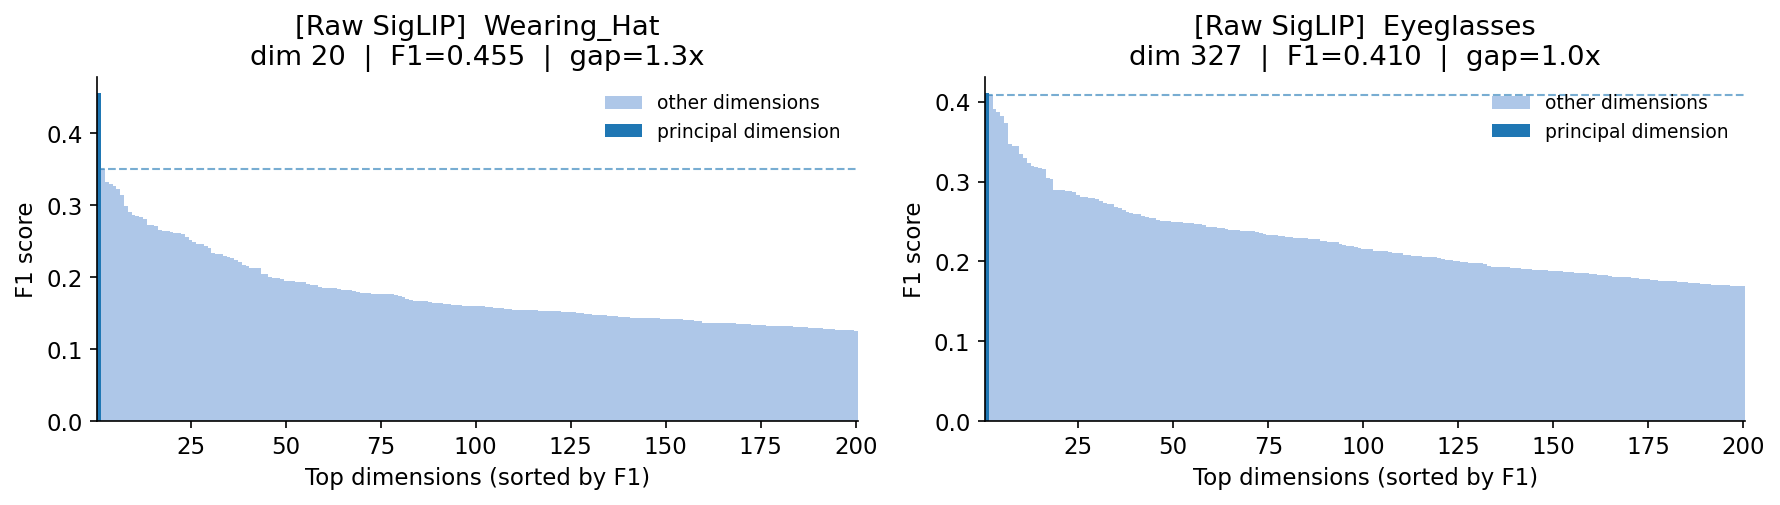

In [2]:
plot_importance(gt_raw, labels_df, RAW_DIR / 'neuron_importance.pdf',
                title_prefix='[Raw SigLIP]  ')

Saved → /nfs/scistore19/locatgrp/rcadei/NEMS/results/celeba/experiment/raw/effect_sweep.pdf


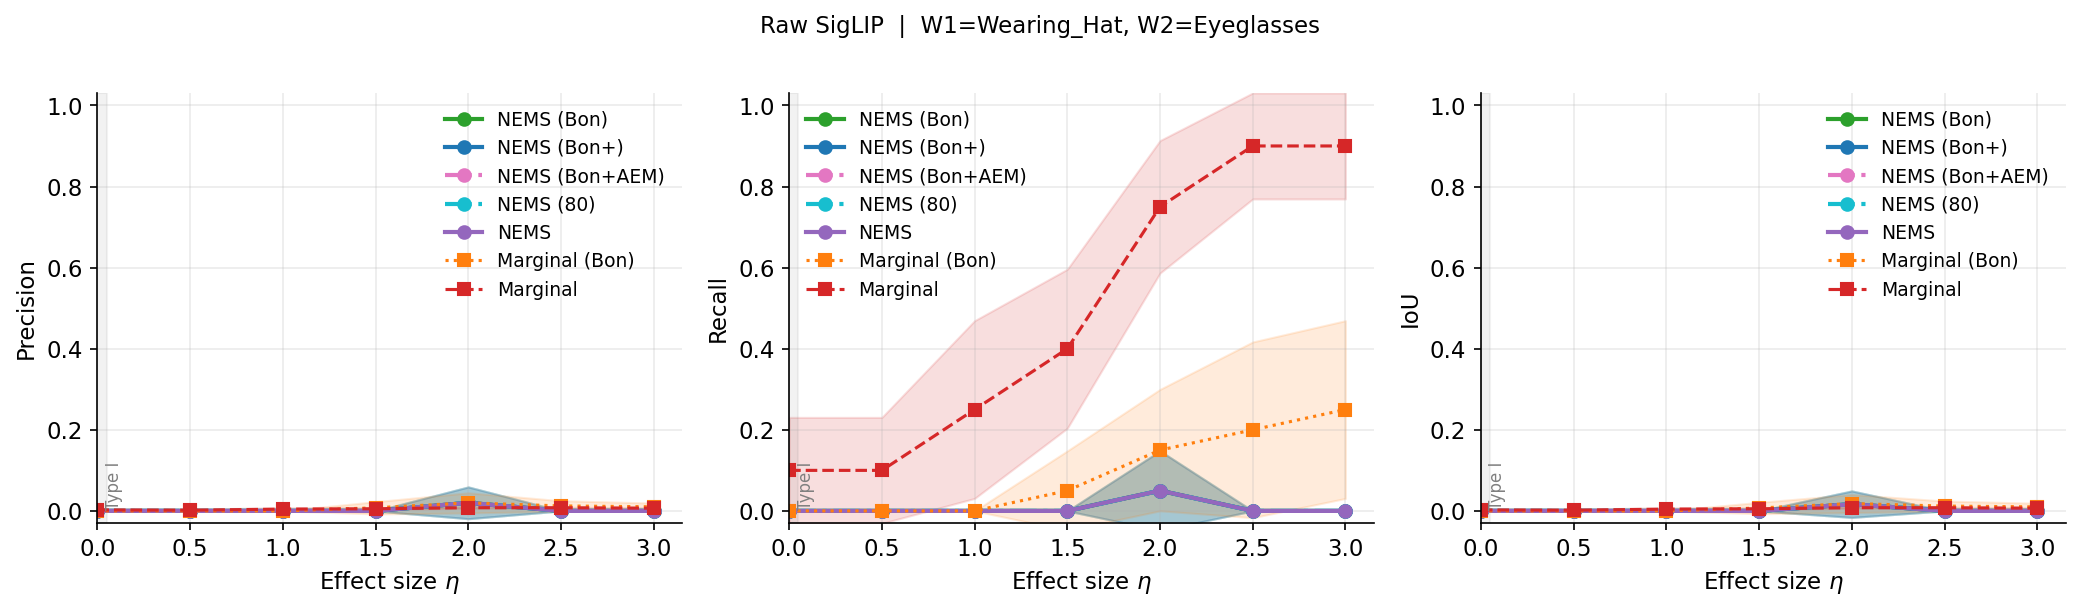

In [3]:
plot_sweep_grid(df_effect_raw, 'effect_scale', r'Effect size $\eta$',
                f'Raw SigLIP  |  W1={gt_raw["w1_attr"]}, W2={gt_raw["w2_attr"]}',
                RAW_DIR / 'effect_sweep.pdf')

Saved → /nfs/scistore19/locatgrp/rcadei/NEMS/results/celeba/experiment/raw/n_sweep.pdf


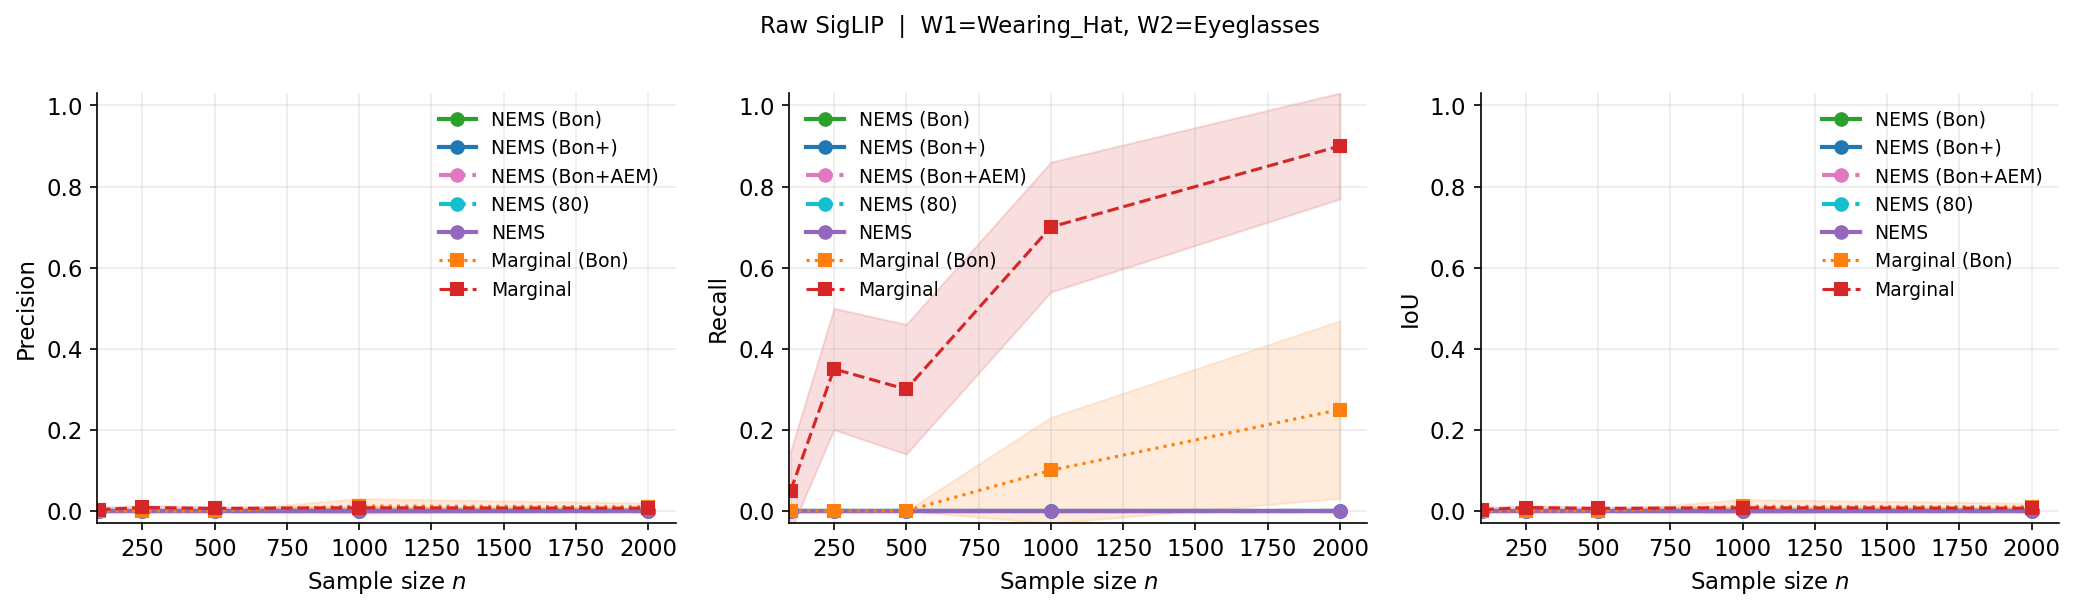

In [4]:
plot_sweep_grid(df_n_raw, 'n', r'Sample size $n$',
                f'Raw SigLIP  |  W1={gt_raw["w1_attr"]}, W2={gt_raw["w2_attr"]}',
                RAW_DIR / 'n_sweep.pdf')

---
## 2a. SigLIP + SAE (k=5) — Pre-activations (9216-dim, continuous)

NEMS regression uses continuous pre-activations (`z_pre`, dense and correlated).
NEMS conditioning removes false positives that Bonferroni misses.

Saved → /nfs/scistore19/locatgrp/rcadei/NEMS/results/celeba/experiment/k5/sae_precode/neuron_importance.pdf
  Wearing_Hat: gap=1.5x  →  not principally aligned
  Eyeglasses: gap=1.4x  →  not principally aligned


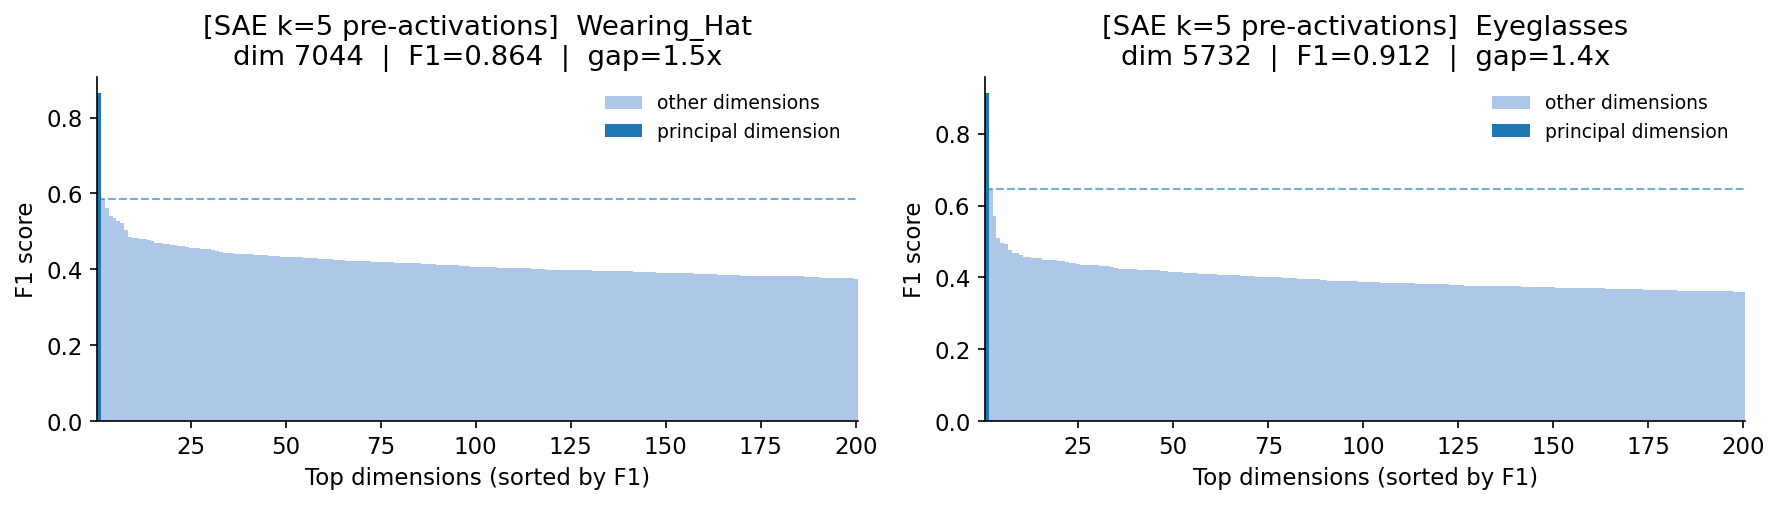

In [5]:
plot_importance(gt_precode_k5, labels_df, PRECODE_K5_DIR / 'neuron_importance.pdf',
                title_prefix='[SAE k=5 pre-activations]  ', precode=True)

Saved → /nfs/scistore19/locatgrp/rcadei/NEMS/results/celeba/experiment/k5/sae_precode/effect_sweep.pdf


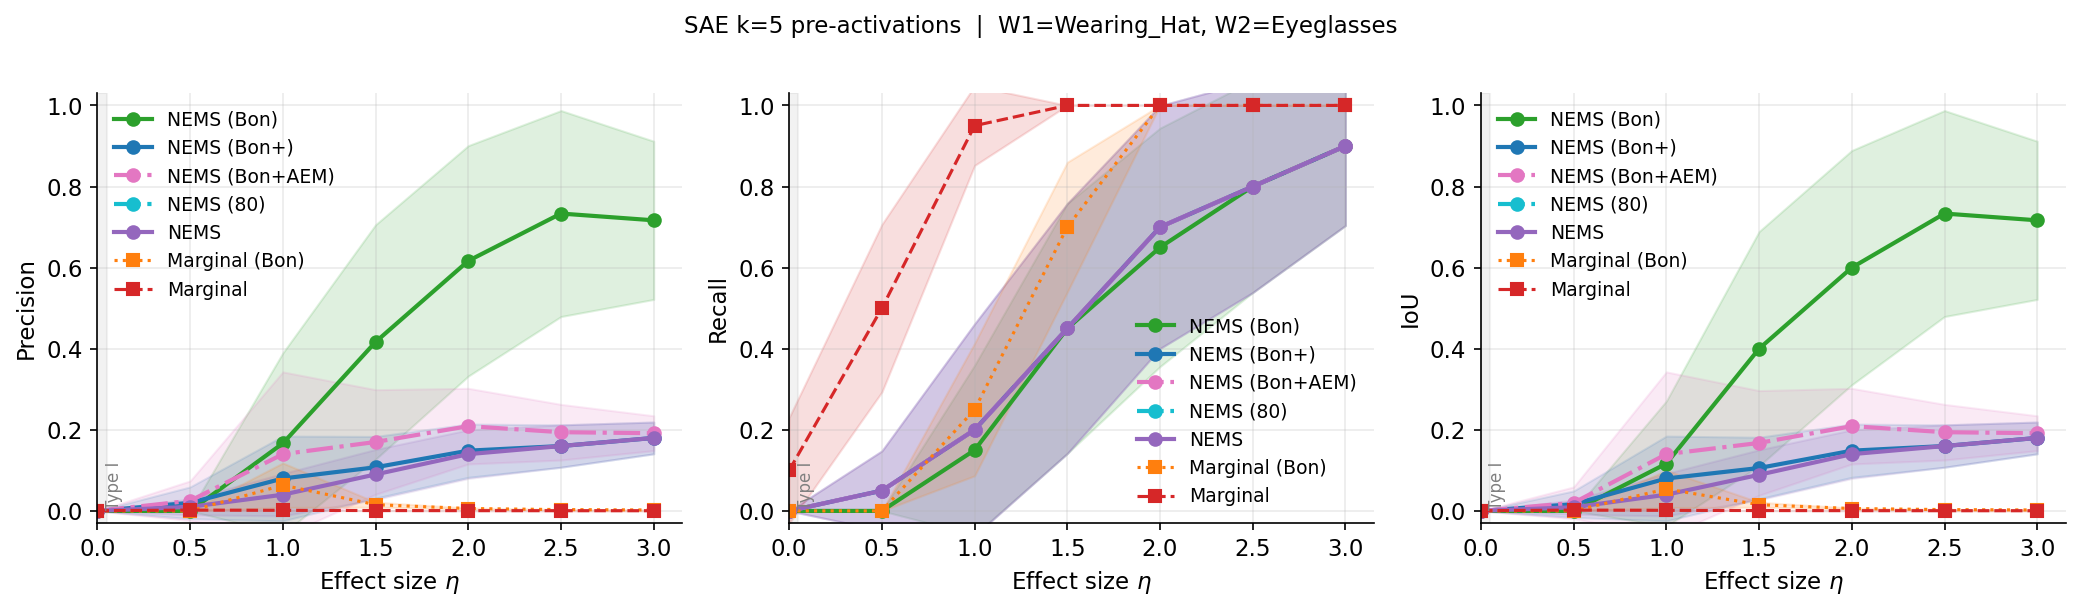

In [6]:
plot_sweep_grid(df_effect_precode_k5, 'effect_scale', r'Effect size $\eta$',
                f'SAE k=5 pre-activations  |  W1={gt_precode_k5["w1_attr"]}, W2={gt_precode_k5["w2_attr"]}',
                PRECODE_K5_DIR / 'effect_sweep.pdf')

Saved → /nfs/scistore19/locatgrp/rcadei/NEMS/results/celeba/experiment/k5/sae_precode/n_sweep.pdf


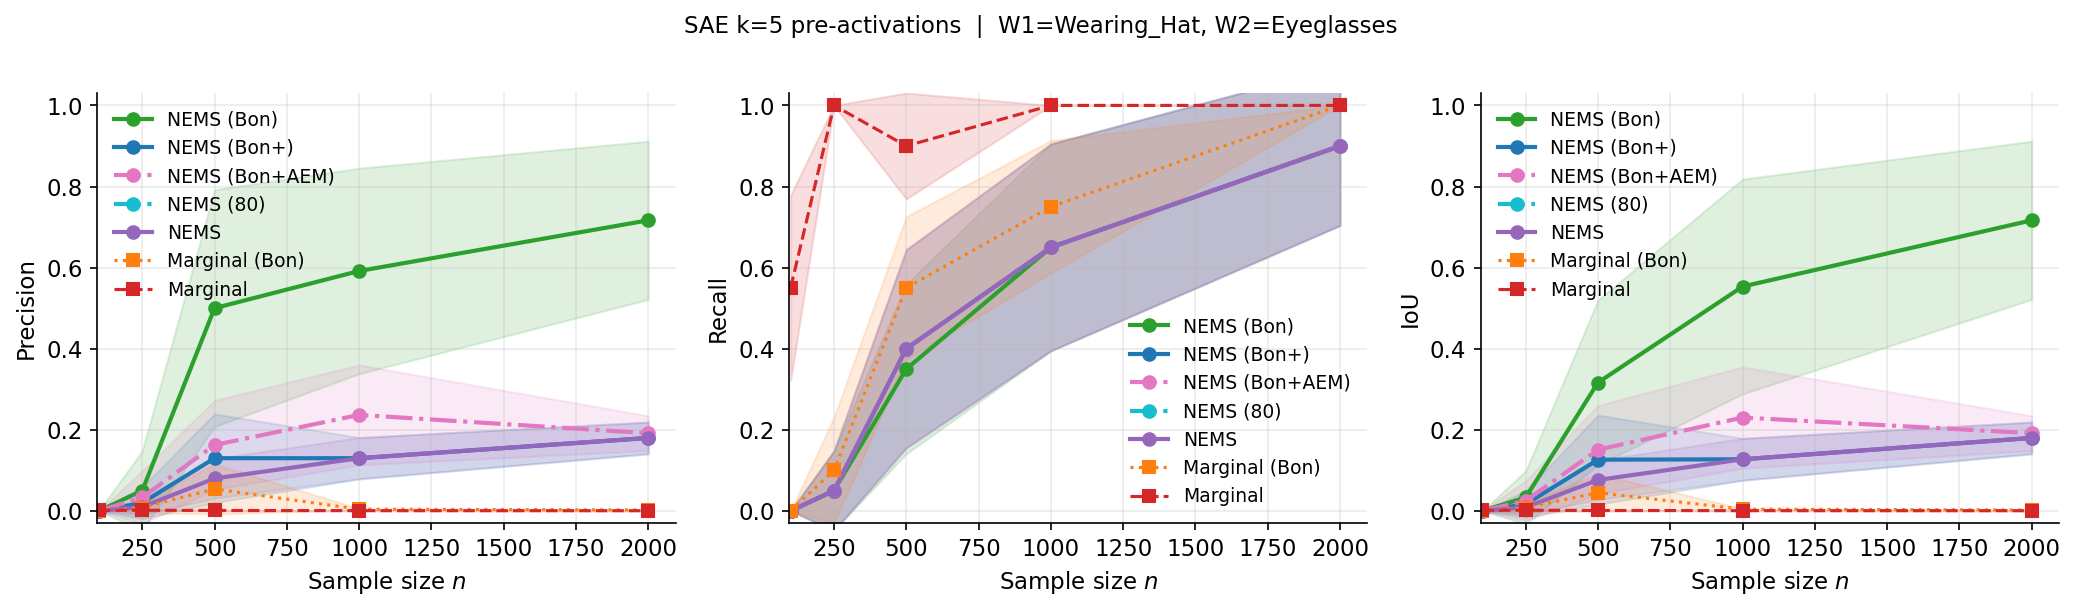

In [7]:
plot_sweep_grid(df_n_precode_k5, 'n', r'Sample size $n$',
                f'SAE k=5 pre-activations  |  W1={gt_precode_k5["w1_attr"]}, W2={gt_precode_k5["w2_attr"]}',
                PRECODE_K5_DIR / 'n_sweep.pdf')

---
## 2b. SigLIP + SAE (k=5) — Sparse Codes (9216-dim, post-TopK)

NEMS regression uses sparse post-TopK codes (`z`, ~orthogonal by design).
NEMS ≈ Bonferroni because conditioning on near-orthogonal features adds no power.

Saved → /nfs/scistore19/locatgrp/rcadei/NEMS/results/celeba/experiment/k5/sae/neuron_importance.pdf
  Wearing_Hat: gap=2.8x  →  PRINCIPALLY ALIGNED
  Eyeglasses: gap=1.8x  →  not principally aligned


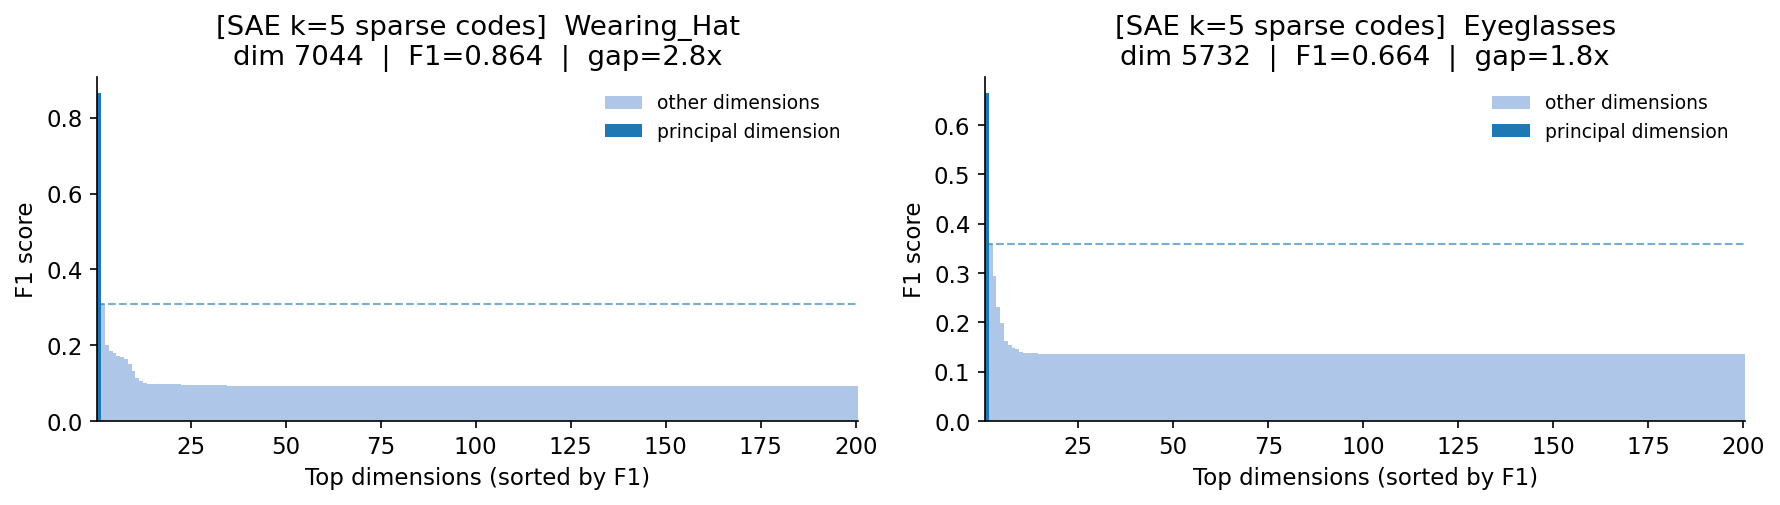

In [8]:
plot_importance(gt_sae_k5, labels_df, SAE_K5_DIR / 'neuron_importance.pdf',
                title_prefix='[SAE k=5 sparse codes]  ')

Saved → /nfs/scistore19/locatgrp/rcadei/NEMS/results/celeba/experiment/k5/sae/effect_sweep.pdf


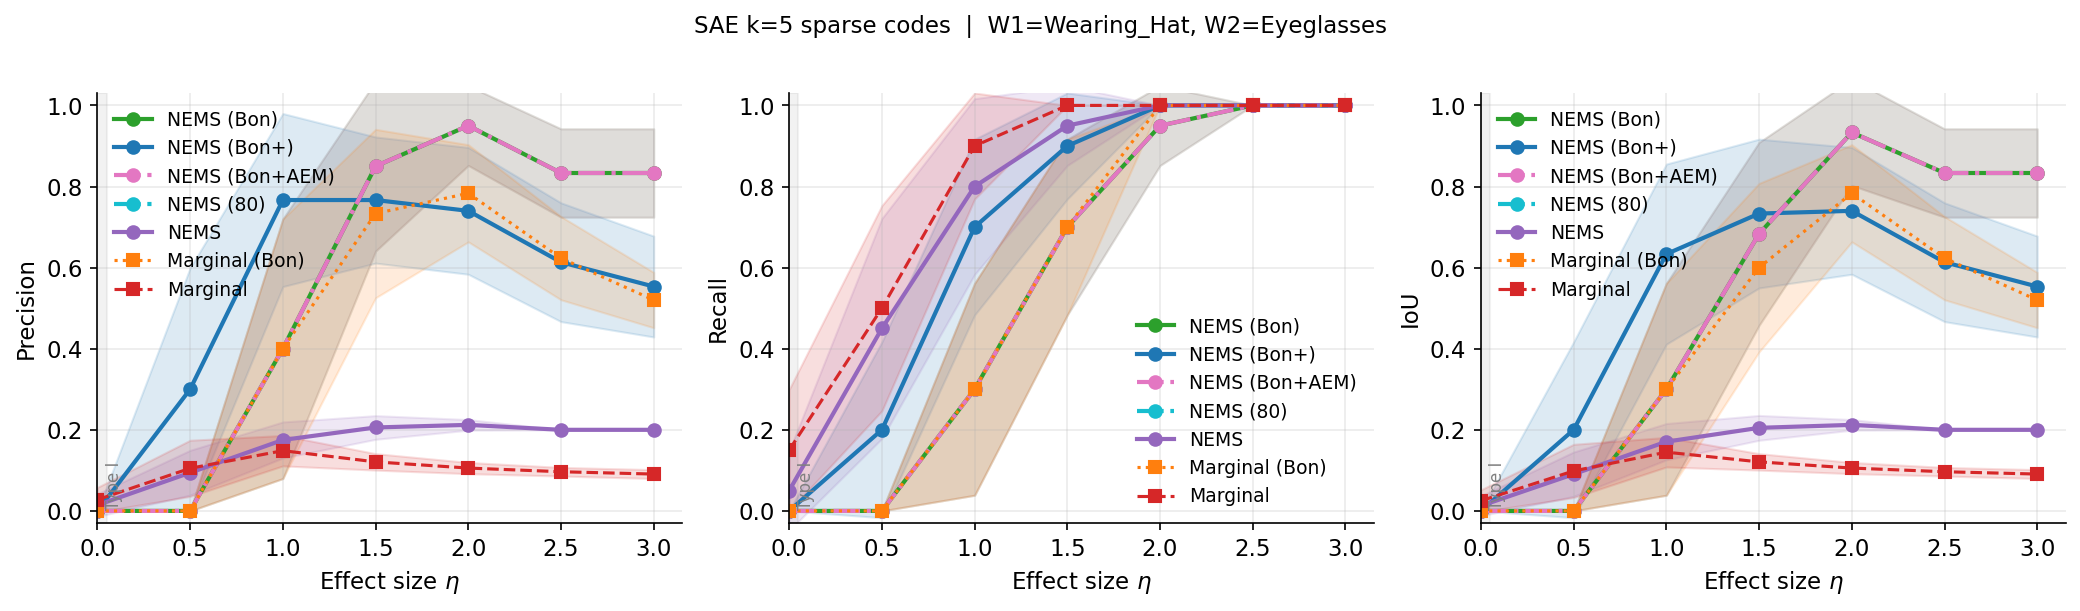

In [9]:
plot_sweep_grid(df_effect_sae_k5, 'effect_scale', r'Effect size $\eta$',
                f'SAE k=5 sparse codes  |  W1={gt_sae_k5["w1_attr"]}, W2={gt_sae_k5["w2_attr"]}',
                SAE_K5_DIR / 'effect_sweep.pdf')

Saved → /nfs/scistore19/locatgrp/rcadei/NEMS/results/celeba/experiment/k5/sae/n_sweep.pdf


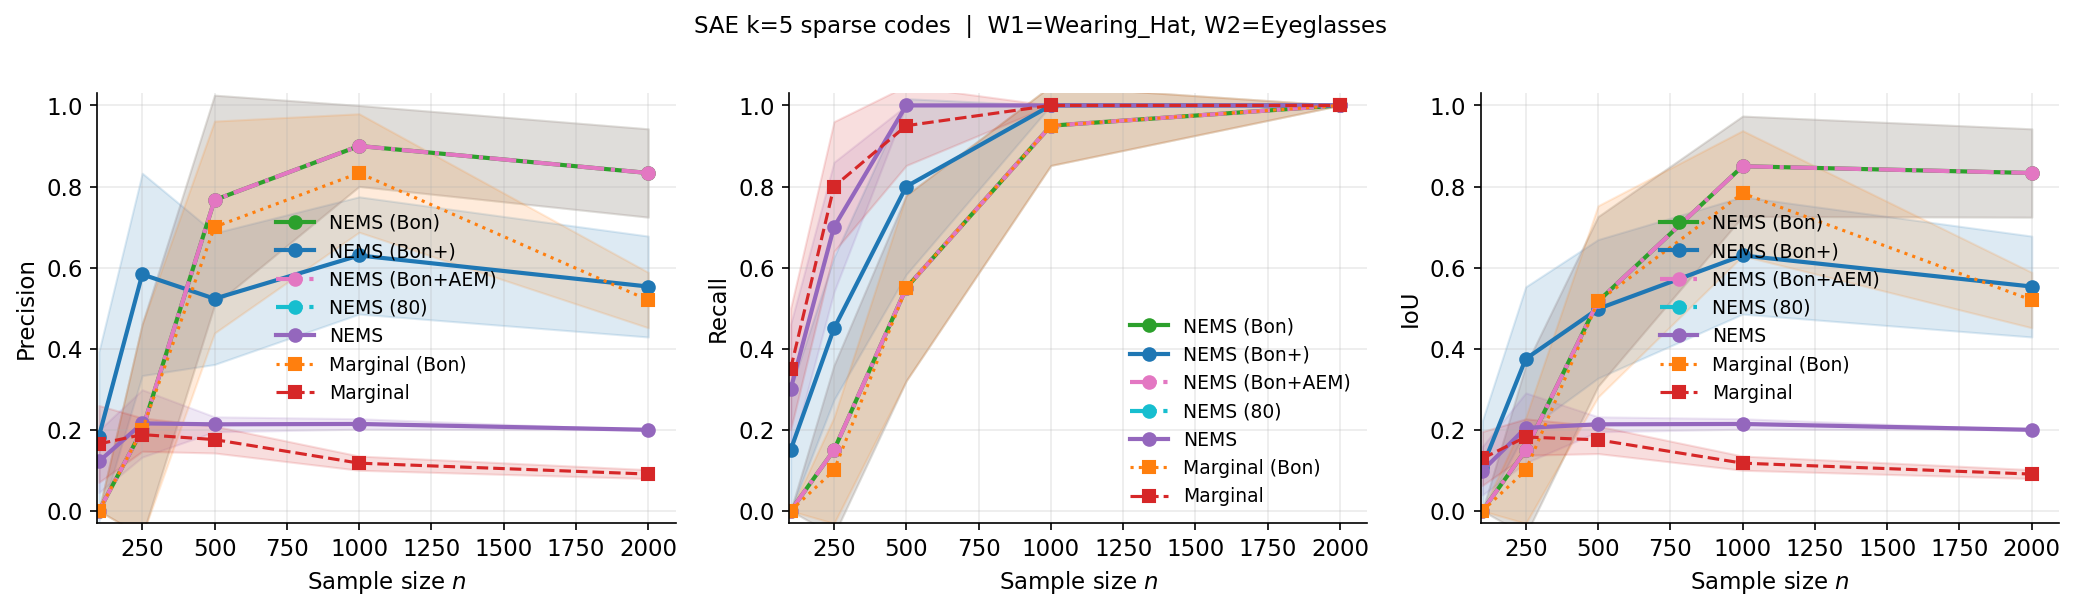

In [10]:
plot_sweep_grid(df_n_sae_k5, 'n', r'Sample size $n$',
                f'SAE k=5 sparse codes  |  W1={gt_sae_k5["w1_attr"]}, W2={gt_sae_k5["w2_attr"]}',
                SAE_K5_DIR / 'n_sweep.pdf')

---
## 3a. SigLIP + SAE (k=20) — Pre-activations (9216-dim, continuous)

Same setup as §2a but with a top-k=20 SAE — each image activates 20 features instead of 5.
Denser codes mean more correlated features; NEMS conditioning should still suppress false positives.

Saved → /nfs/scistore19/locatgrp/rcadei/NEMS/results/celeba/experiment/k20/sae_precode/neuron_importance.pdf
  Wearing_Hat: gap=1.6x  →  not principally aligned
  Eyeglasses: gap=1.3x  →  not principally aligned


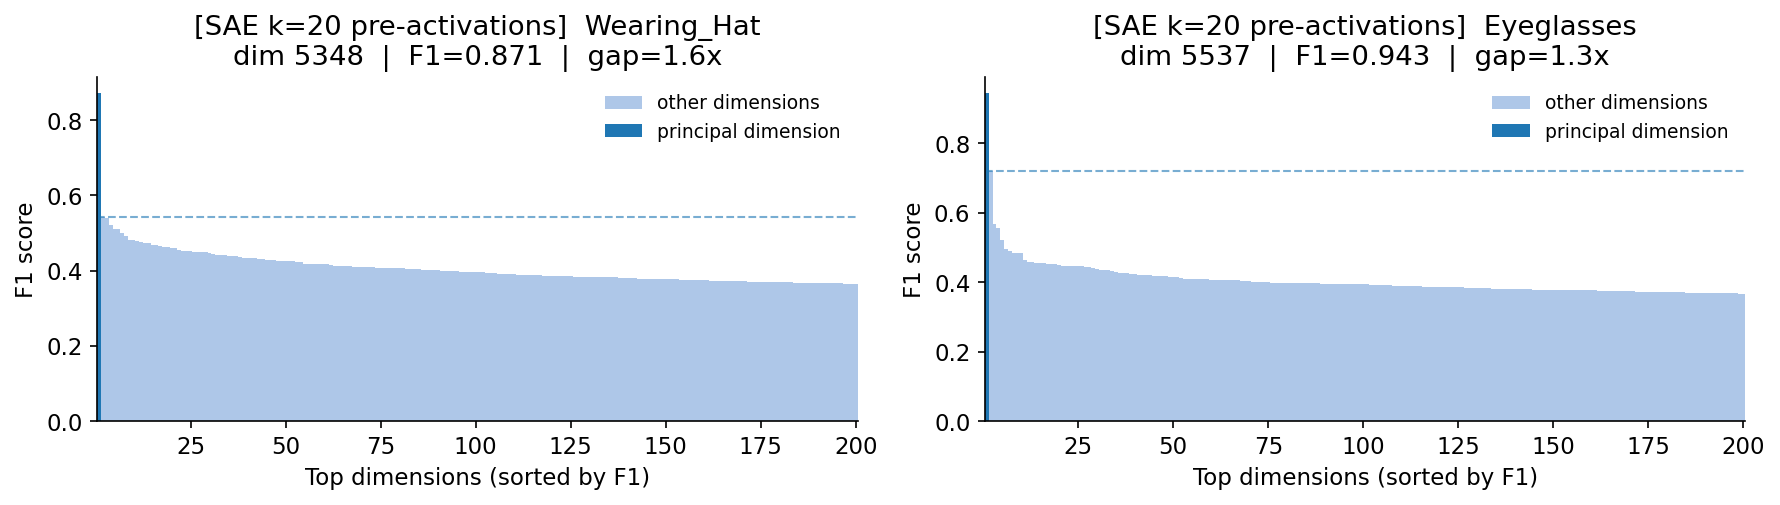

In [11]:
plot_importance(gt_precode_k20, labels_df, PRECODE_K20_DIR / 'neuron_importance.pdf',
                title_prefix='[SAE k=20 pre-activations]  ', precode=True)

Saved → /nfs/scistore19/locatgrp/rcadei/NEMS/results/celeba/experiment/k20/sae_precode/effect_sweep.pdf


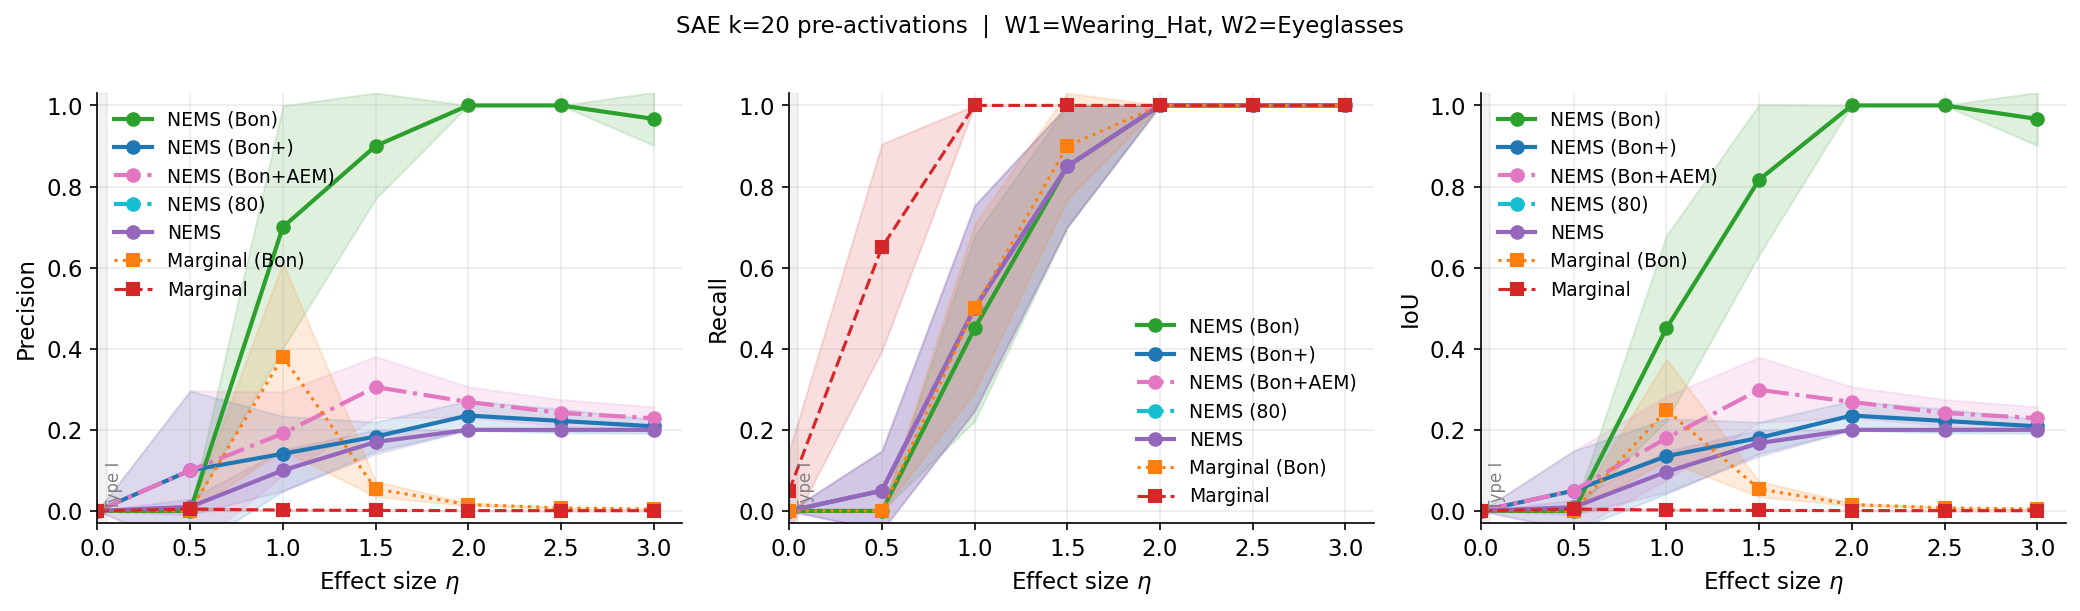

In [12]:
plot_sweep_grid(df_effect_precode_k20, 'effect_scale', r'Effect size $\eta$',
                f'SAE k=20 pre-activations  |  W1={gt_precode_k20["w1_attr"]}, W2={gt_precode_k20["w2_attr"]}',
                PRECODE_K20_DIR / 'effect_sweep.pdf')

Saved → /nfs/scistore19/locatgrp/rcadei/NEMS/results/celeba/experiment/k20/sae_precode/n_sweep.pdf


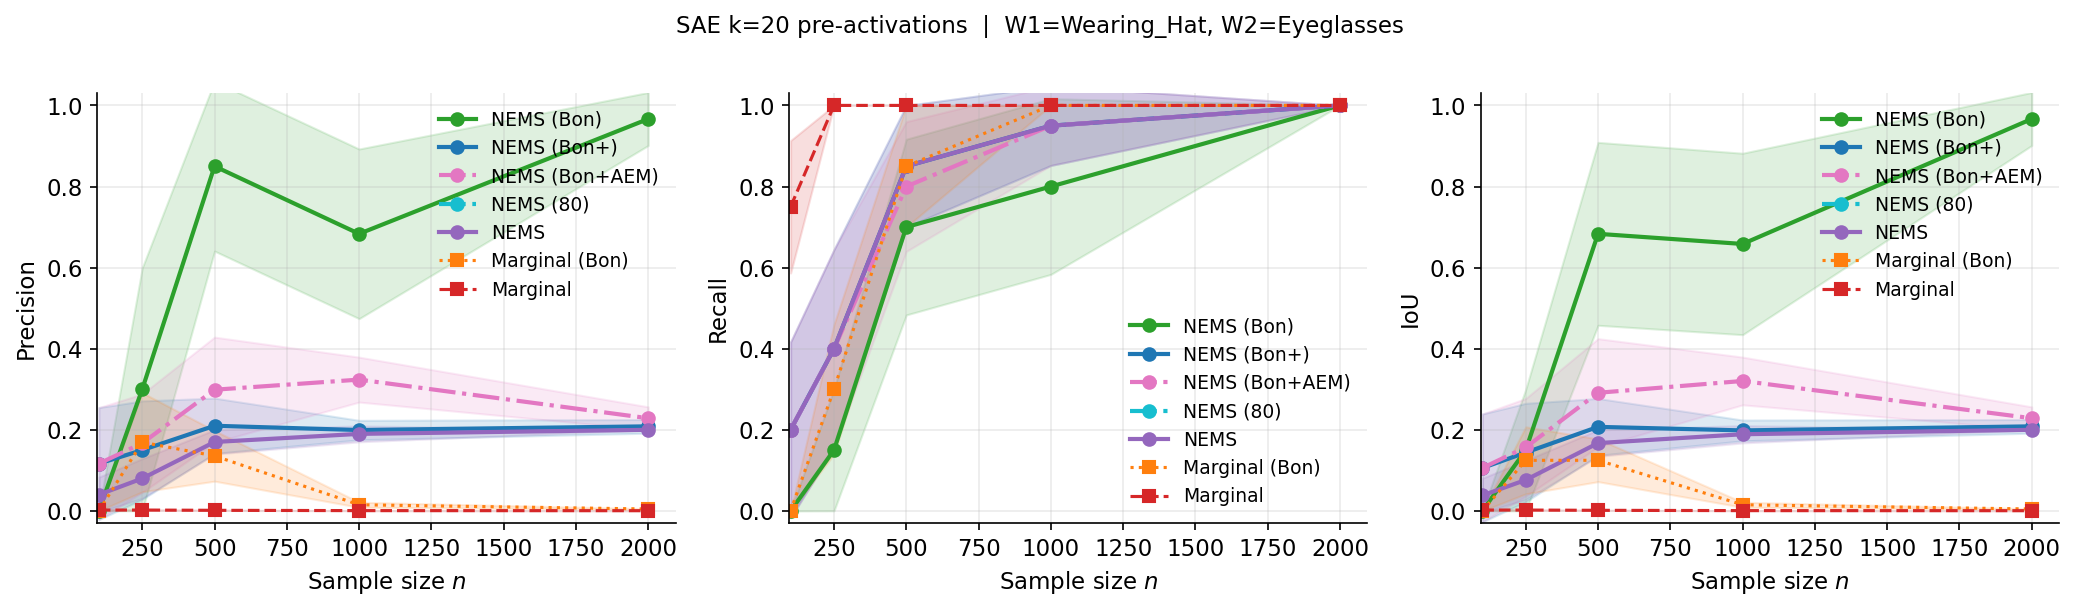

In [13]:
plot_sweep_grid(df_n_precode_k20, 'n', r'Sample size $n$',
                f'SAE k=20 pre-activations  |  W1={gt_precode_k20["w1_attr"]}, W2={gt_precode_k20["w2_attr"]}',
                PRECODE_K20_DIR / 'n_sweep.pdf')

---
## 3b. SigLIP + SAE (k=20) — Sparse Codes (9216-dim, post-TopK)

Same setup as §2b but with top-k=20 — 20 features active per image instead of 5.
Codes are sparser than pre-activations but denser than k=5; NEMS ≈ Bonferroni expected.

Saved → /nfs/scistore19/locatgrp/rcadei/NEMS/results/celeba/experiment/k20/sae/neuron_importance.pdf
  Wearing_Hat: gap=2.4x  →  PRINCIPALLY ALIGNED
  Eyeglasses: gap=1.6x  →  not principally aligned


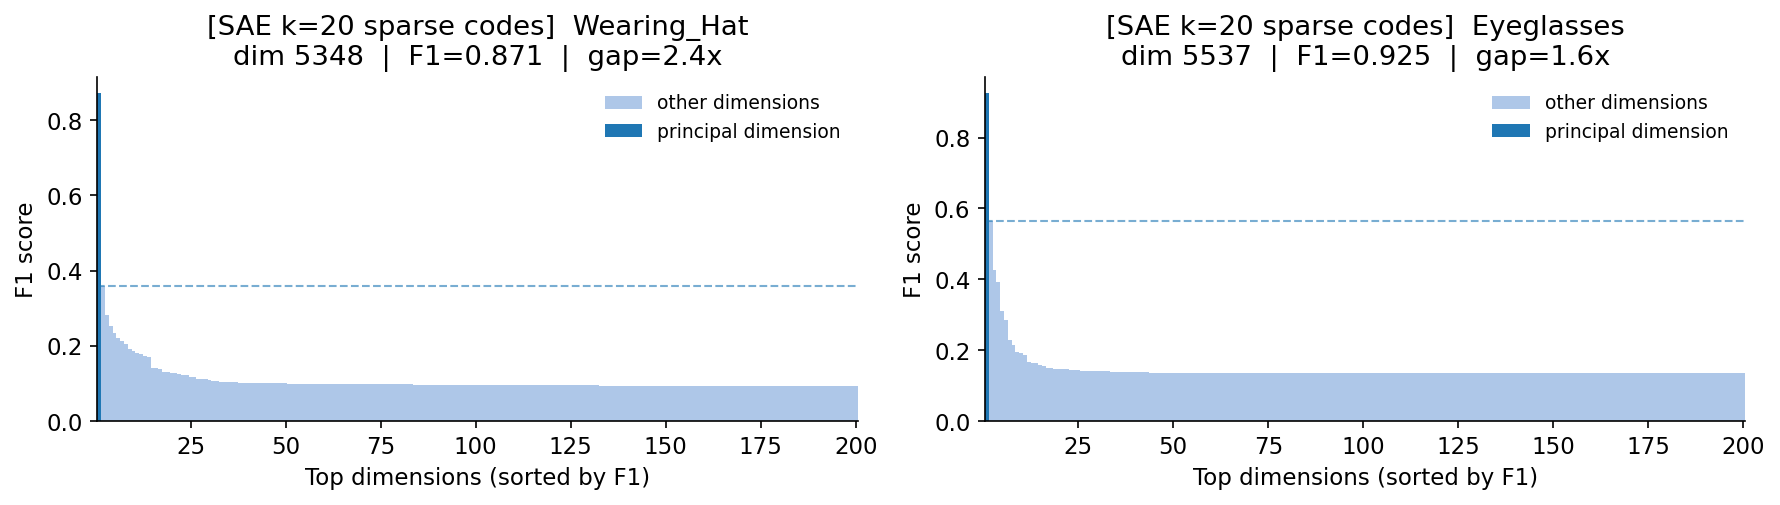

In [14]:
plot_importance(gt_sae_k20, labels_df, SAE_K20_DIR / 'neuron_importance.pdf',
                title_prefix='[SAE k=20 sparse codes]  ')

Saved → /nfs/scistore19/locatgrp/rcadei/NEMS/results/celeba/experiment/k20/sae/effect_sweep.pdf


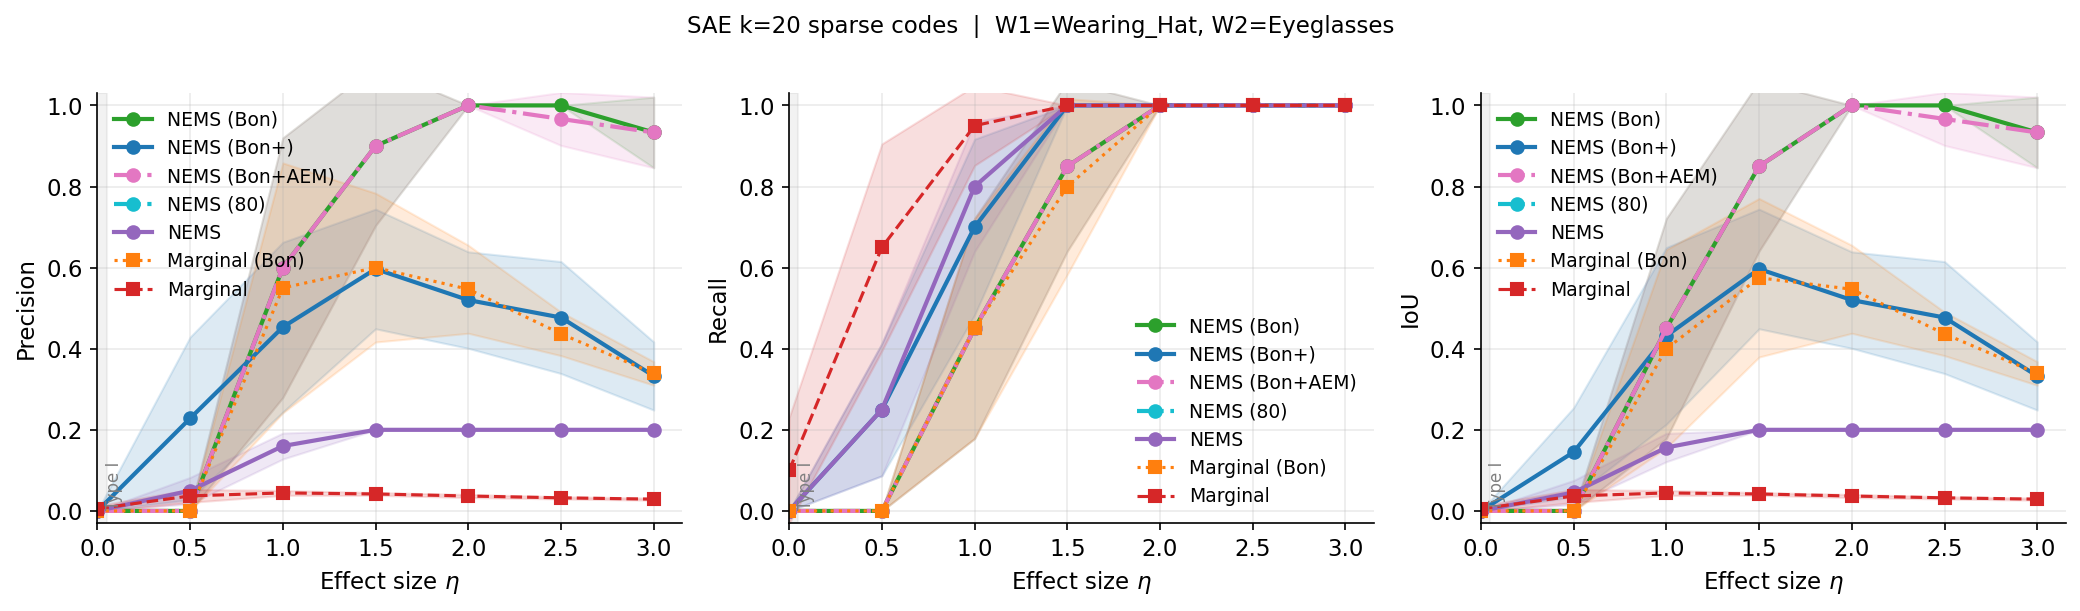

In [15]:
plot_sweep_grid(df_effect_sae_k20, 'effect_scale', r'Effect size $\eta$',
                f'SAE k=20 sparse codes  |  W1={gt_sae_k20["w1_attr"]}, W2={gt_sae_k20["w2_attr"]}',
                SAE_K20_DIR / 'effect_sweep.pdf')

Saved → /nfs/scistore19/locatgrp/rcadei/NEMS/results/celeba/experiment/k20/sae/n_sweep.pdf


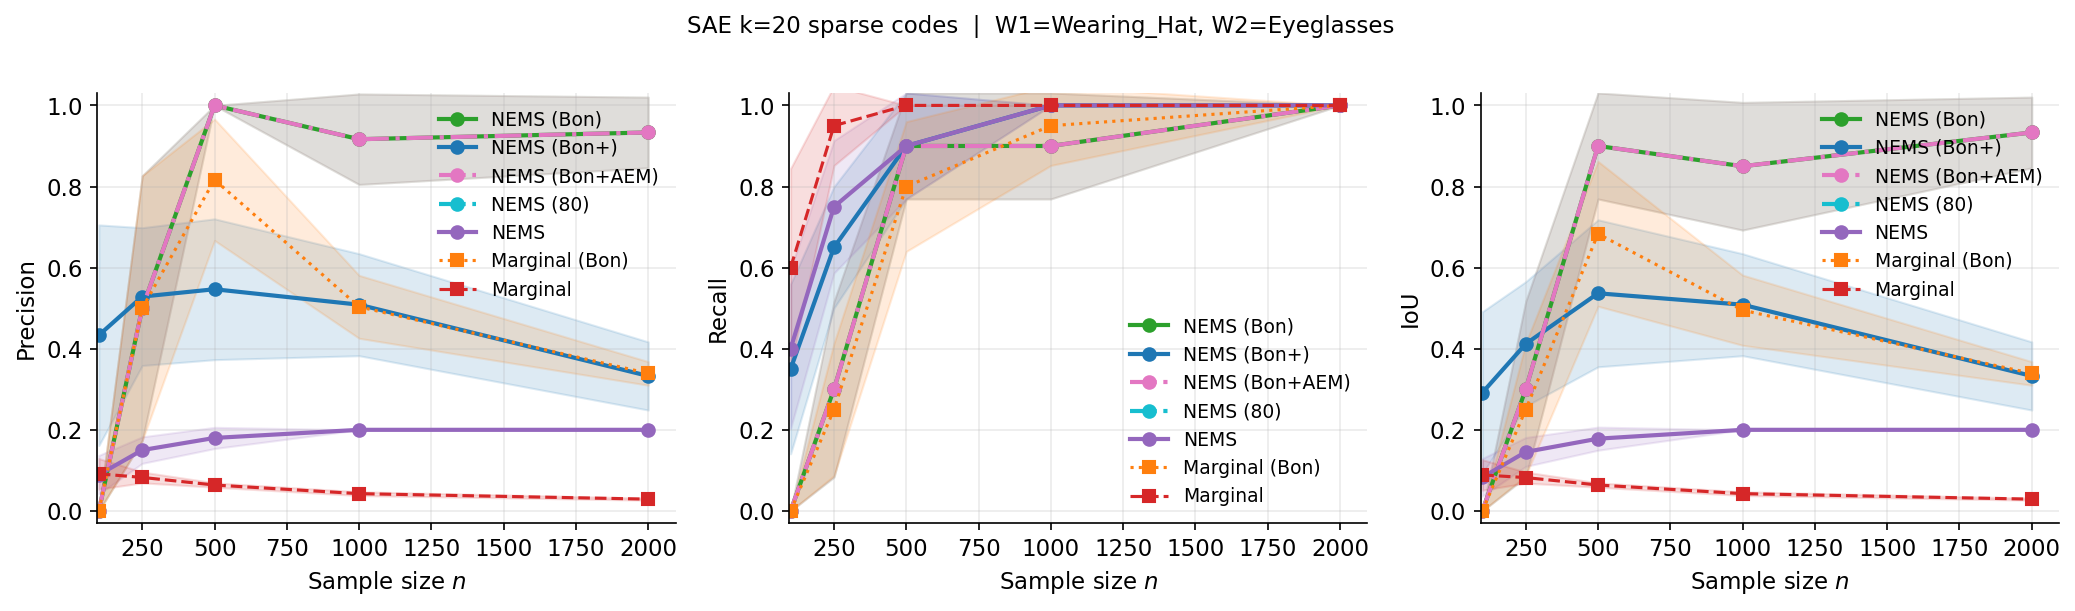

In [16]:
plot_sweep_grid(df_n_sae_k20, 'n', r'Sample size $n$',
                f'SAE k=20 sparse codes  |  W1={gt_sae_k20["w1_attr"]}, W2={gt_sae_k20["w2_attr"]}',
                SAE_K20_DIR / 'n_sweep.pdf')